# Portfolio analysis with the saved risk model

Loads the model saved by `style_factors.ipynb` (the `model/` directory) — no raw data,
loads in milliseconds. Weights are fractions of NAV: net ≠ 1 and short weights are fine;
tickers outside the model universe are warned about and ignored.

In [1]:
from risk_model import RiskModel

m = RiskModel.load('model')
m.meta

{'fit_date': '2026-08-07',
 'window': ['2018-11-20', '2026-08-07'],
 'n_days': 1937,
 'n_names': 503,
 'mean_xsec_r2': 0.3798,
 'style_factors': ['Beta', 'Momentum', 'Size', 'ResVol'],
 'annualization': 252,
 'factor_cov_params': {'vol_half_life': 84,
  'corr_half_life': 504,
  'nw_lags_var': 5,
  'nw_lags_corr': 2},
 'specific_var_params': {'half_life': 84, 'nw_lags': 5},
 'notes': 'exposures z-scored to EW mean 0 / std 1, lagged 1 day; Size = log 63d median dollar volume (size/liquidity proxy)'}

## Example 1 — concentrated mega-cap tech book

High factor vol (all one sector, high-beta names) *and* meaningful specific risk
(only five names — diversification hasn't killed the idiosyncratic term).

In [2]:
tech = {'AAPL': 0.20, 'MSFT': 0.20, 'NVDA': 0.20, 'GOOGL': 0.20, 'AMZN': 0.20}
d = m.report(tech)

net +1.00  gross 1.00   (model fit: 2026-08-07)
total vol    :  23.89%
  factor     :  19.81%   (68.8% of variance)
  specific   :  13.35%   (31.2% of variance)
style exposures (z-units): Beta -0.14  Momentum +0.30  Size +3.07  ResVol +0.33

top factor variance contributors:
Information Technology    0.316
Size                      0.229
Communication Services    0.065
Consumer Discretionary    0.060
ResVol                    0.033
Momentum                  0.010

top specific variance contributors:
AMZN     0.080
AAPL     0.067
GOOGL    0.060
NVDA     0.053
MSFT     0.052


## Example 2 — dollar-neutral long/short

Long integrated energy, short regulated utilities, net exposure zero. Sector risk
dominates by construction; note the style tilts the book picks up along the way.

In [3]:
ls = {'XOM': 0.33, 'CVX': 0.33, 'COP': 0.34,
      'NEE': -0.33, 'DUK': -0.33, 'SO': -0.34}
d = m.report(ls)

net -0.00  gross 2.00   (model fit: 2026-08-07)
total vol    :  24.82%
  factor     :  22.66%   (83.3% of variance)
  specific   :  10.15%   (16.7% of variance)
style exposures (z-units): Beta -0.99  Momentum +0.03  Size +0.83  ResVol +0.12

top factor variance contributors:
Utilities                 0.331
Energy                    0.320
Beta                      0.179
Size                      0.003
ResVol                    0.001
Communication Services   -0.000

top specific variance contributors:
NEE    0.047
COP    0.035
XOM    0.034
CVX    0.029
SO     0.012
DUK    0.011


## Custom thematic factor — "AI"

`add_factor(name, symbols)` turns any basket of stocks into a new factor **without
refitting**. Its daily return is the equal-weighted mean *residual* return of the basket —
the co-movement that sectors and styles do **not** already explain (so it won't just
re-measure "these are tech stocks"). The basket names get a 0/1 exposure to it, the
factor covariance grows a row empirically, and their specific risk drops by what the
factor absorbs. The rigorous alternative — refitting the daily regressions with the
dummy included — lives in `style_factors.ipynb`.

In [4]:
ai_names = ['NVDA', 'MSFT', 'GOOGL', 'META', 'AMZN', 'AVGO', 'AMD', 'ORCL', 'ANET', 'PLTR']
f_ai = m.add_factor('AI', ai_names)

added factor 'AI': 10 names, annualized vol 11.3%, max |corr| with existing factors 0.24


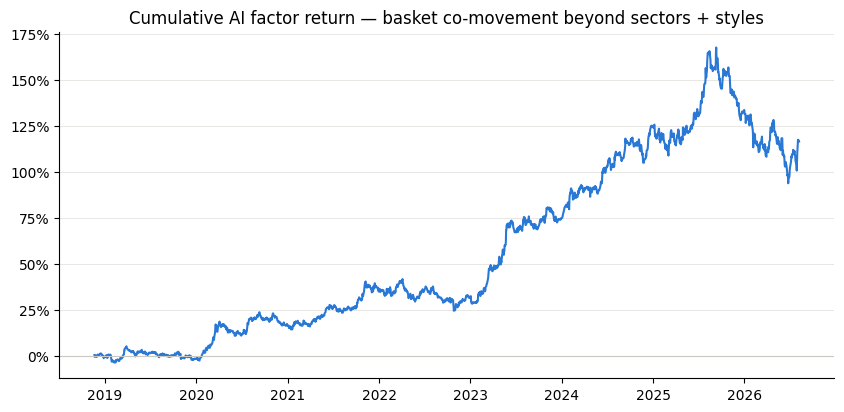

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(f_ai.index, (1 + f_ai).cumprod() - 1, lw=1.5, color='#2a78d6')
ax.axhline(0, color='#c9c8c2', lw=0.8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
for s in ('top', 'right'): ax.spines[s].set_visible(False)
ax.grid(axis='y', color='#e8e7e3', lw=0.7)
ax.set_title('Cumulative AI factor return — basket co-movement beyond sectors + styles')
plt.show()

An AI-tilted book now shows "AI" as an explicit risk source (60% of this
portfolio sits in the basket):

In [6]:
ai_tilted = {'NVDA': 0.20, 'AMD': 0.15, 'PLTR': 0.15, 'JPM': 0.20, 'XOM': 0.15, 'JNJ': 0.15}
d = m.report(ai_tilted)

net +1.00  gross 1.00   (model fit: 2026-08-07)
total vol    :  24.37%
  factor     :  20.97%   (74.0% of variance)
  specific   :  12.42%   (26.0% of variance)
style exposures (z-units): Beta -0.05  Momentum +0.84  Size +1.86  ResVol +0.14
custom factor exposures (basket weight): AI +0.50

top factor variance contributors:
Information Technology    0.237
AI                        0.164
Size                      0.116
Momentum                  0.086
Financials                0.053
Energy                    0.042

top specific variance contributors:
PLTR    0.100
AMD     0.084
NVDA    0.044
JNJ     0.012
JPM     0.012
XOM     0.007


In [7]:
m.save('model_ai')                      # persist; RiskModel.load('model_ai') includes AI
sorted(p.name for p in __import__('pathlib').Path('model_ai').iterdir())

['exposures.csv',
 'factor_cov.csv',
 'factor_returns.csv',
 'meta.json',
 'residual_returns.csv.gz',
 'sectors.csv',
 'specific_var.csv']

## Half-life control

The saved model carries USE4-style half-lives (factor vol 84d / correlation 504d /
specific 84d, all Newey-West adjusted). `refit_covariance()` re-estimates $F$ and $D$
from the stored history with any half-lives you like — shorter = more reactive to the
current vol regime, longer = steadier. It is custom-factor aware (the AI factor's row
and its names' reduced specific risk survive the refit).

In [8]:
v84 = m.decompose(tech)['total_vol']
m.refit_covariance(vol_half_life=21)                 # very reactive vol snapshot
v21 = m.decompose(tech)['total_vol']
m.refit_covariance()                                 # back to USE4 defaults
print(f'\ntech book vol:  HL 84d {v84:.2%}   HL 21d {v21:.2%}')

refit: factor vol HL 21d / corr HL 504d / specific HL 84d (Newey-West 5/2/5 lags)
refit: factor vol HL 84d / corr HL 504d / specific HL 84d (Newey-West 5/2/5 lags)

tech book vol:  HL 84d 29.35%   HL 21d 32.52%


## Other entry points

- `m.exposures(w)` — the 15 factor exposures of any weight vector
- `m.decompose(w)` — the full decomposition as a dict (for further computation)
- `m.covariance([...])` — model-implied asset covariance block for any symbols
- `m.factor_returns` — daily factor return history, for attribution or plots

In [9]:
m.covariance(['AAPL', 'MSFT', 'XOM', 'NEE']).round(4)

,AAPL,MSFT,XOM,NEE
AAPL,0.1515,0.0527,-0.0077,0.0017
MSFT,0.0527,0.1452,-0.0062,-0.0005
XOM,-0.0077,-0.0062,0.0780,0.0091
NEE,0.0017,-0.0005,0.0091,0.0468
